# Business Data Analytics Final Project: IMDb Movie Dataset
**Objective:** To perform a complete end-to-end data analytics workflow on the IMDb dataset, including data ingestion, cleaning, statistical analysis, exploratory data analysis (EDA), predictive modeling (regression and classification), and deployment prototyping.

## 1. Environment Setup & Library Imports
First, we will install any required packages (like Streamlit for our deployment prototype) and import the necessary libraries for data processing, visualization, and machine learning.

In [1]:
# Install streamlit for the final deployment prototype
!pip install -q streamlit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

# Sklearn imports for machine learning pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# Configuration for reproducibility and visual aesthetics
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
np.random.seed(42)

print("Environment setup complete. Libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.2 MB/s eta 0:00:00
Environment setup complete. Libraries imported successfully.


## 2. Data Loading and Merging
The IMDb datasets are large. To optimize memory, we will:
- Specify `usecols` to load only the necessary columns.
- Treat the string `\N` as missing values (NaN) which is IMDb's default missing value marker.
- Use an inner join on the common key `tconst` to merge the basics and ratings datasets.

In [2]:
# Define paths (assuming files are uploaded directly to the Colab workspace)
basics_path = 'title.basics.tsv_2'
ratings_path = 'title.ratings.tsv_2'

# Load basics data
# We specify columns to save memory.
cols_to_use = ['tconst', 'titleType', 'primaryTitle', 'startYear', 'runtimeMinutes', 'genres']
print("Loading basics dataset...")
df_basics = pd.read_csv(
    basics_path,
    sep='\t',
    na_values=['\\N'],
    usecols=cols_to_use,
    low_memory=False
)

# Load ratings data
print("Loading ratings dataset...")
df_ratings = pd.read_csv(
    ratings_path,
    sep='\t',
    na_values=['\\N']
)

# Merge datasets using an inner join
print("Merging datasets on 'tconst'...")
df = pd.merge(df_basics, df_ratings, on='tconst', how='inner')

# Display basic dataset information
print("\n--- Merged Dataset Info ---")
df.info()

print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Descriptive Statistics (Raw Data) ---")
display(df.describe(include='all'))

Loading basics dataset...
Loading ratings dataset...
Merging datasets on 'tconst'...

--- Merged Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478102 entries, 0 to 478101
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          478102 non-null  object 
 1   titleType       478102 non-null  object 
 2   primaryTitle    478102 non-null  object 
 3   startYear       478078 non-null  float64
 4   runtimeMinutes  390251 non-null  float64
 5   genres          466195 non-null  object 
 6   averageRating   478102 non-null  float64
 7   numVotes        478102 non-null  int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 29.2+ MB

--- Dataset Shape ---
Rows: 478,102, Columns: 8

--- First 5 Rows ---


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000001,short,Carmencita,1894.0,1.0,"Documentary,Short",5.7,2216
1,tt0000002,short,Le clown et ses chiens,1892.0,5.0,"Animation,Short",5.5,318
2,tt0000003,short,Poor Pierrot,1892.0,5.0,"Animation,Comedy,Romance",6.4,2334
3,tt0000004,short,Un bon bock,1892.0,12.0,"Animation,Short",5.1,199
4,tt0000005,short,Blacksmith Scene,1893.0,1.0,Short,6.2,3052



--- Descriptive Statistics (Raw Data) ---


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes
count,478102,478102,478102,478078.000000,390251.000000,466195,478102.000000,4.781020e+05
unique,478102,10,388836,NaN,NaN,1628,NaN,NaN
top,tt10110942,tvEpisode,Pilot,NaN,NaN,Comedy,NaN,NaN
freq,1,183057,626,NaN,NaN,46847,NaN,NaN
mean,NaN,NaN,NaN,1983.548295,62.819232,NaN,6.693118,1.722056e+03
std,NaN,NaN,NaN,23.036668,49.304742,NaN,1.322160,2.695088e+04
min,NaN,NaN,NaN,1888.000000,0.000000,NaN,1.000000,5.000000e+00
25%,NaN,NaN,NaN,1971.000000,29.000000,NaN,5.900000,1.800000e+01
50%,NaN,NaN,NaN,1991.000000,60.000000,NaN,6.900000,4.700000e+01
75%,NaN,NaN,NaN,2001.000000,90.000000,NaN,7.600000,1.680000e+02


## 3. Data Cleaning
Raw data contains missing values, invalid types, and extreme outliers. We will:
1. Ensure numeric columns are properly cast as floats.
2. Drop duplicates.
3. Handle missing values (drop rows missing crucial targets or features).
4. Remove extreme outliers in `runtimeMinutes` (e.g., > 300 mins) and filter for items with a substantial number of votes to ensure rating reliability.
5. Randomly sample the dataset to a manageable size (100,000 rows) for memory-efficient machine learning training.

In [3]:
# Convert appropriate columns to numeric
df['startYear'] = pd.to_numeric(df['startYear'], errors='coerce')
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')

# Remove exact duplicate rows
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate rows.")

# Drop rows with missing critical values
df = df.dropna(subset=['averageRating', 'numVotes', 'startYear', 'runtimeMinutes', 'titleType', 'genres'])
print(f"Rows after dropping missing critical values: {len(df):,}")

# Outlier filtering
# Keep items with runtime between 10 and 300 minutes, and at least 100 votes
df = df[(df['runtimeMinutes'] >= 10) & (df['runtimeMinutes'] <= 300)]
df = df[df['numVotes'] >= 100]
print(f"Rows after outlier filtering: {len(df):,}")

# Sample dataset for performance (to prevent Colab RAM crashes during matrix operations)
SAMPLE_SIZE = 100000
if len(df) > SAMPLE_SIZE:
    df_clean = df.sample(n=SAMPLE_SIZE, random_state=42).copy()
    print(f"\nSampled dataset down to {SAMPLE_SIZE:,} rows for modeling.")
else:
    df_clean = df.copy()

# Check final cleaning state
print("\nMissing values in cleaned dataset:")
print(df_clean.isnull().sum())

Removed 0 duplicate rows.
Rows after dropping missing critical values: 383,819
Rows after outlier filtering: 149,919

Sampled dataset down to 100,000 rows for modeling.

Missing values in cleaned dataset:
tconst            0
titleType         0
primaryTitle      0
startYear         0
runtimeMinutes    0
genres            0
averageRating     0
numVotes          0
dtype: int64


## 4. Statistical Analysis
Here we compute core statistical measures: mean, median, mode, variance, and standard deviation. We also calculate the moving average/rolling mean of movie ratings over the years to identify historical trends, alongside a correlation matrix.

In [4]:
numeric_cols = ['startYear', 'runtimeMinutes', 'averageRating', 'numVotes']

print("--- Central Tendency & Dispersion ---")
stats_df = pd.DataFrame({
    'Mean': df_clean[numeric_cols].mean(),
    'Median': df_clean[numeric_cols].median(),
    'Mode': df_clean[numeric_cols].mode().iloc[0], # First mode
    'Variance': df_clean[numeric_cols].var(),
    'Std Dev': df_clean[numeric_cols].std(),
    'Min': df_clean[numeric_cols].min(),
    'Max': df_clean[numeric_cols].max()
})
display(stats_df)

# Rolling Mean / Moving Average Analysis
# Calculate the average rating per year, then apply a 5-year rolling average
yearly_stats = df_clean.groupby('startYear')['averageRating'].mean().sort_index()
rolling_avg = yearly_stats.rolling(window=5).mean()

print("\n--- 5-Year Rolling Average of Ratings (Last 10 Years) ---")
display(pd.DataFrame({'Yearly Avg': yearly_stats, '5-Year Rolling Avg': rolling_avg}).tail(10))

# Correlation Matrix
print("\n--- Correlation Matrix ---")
display(df_clean[numeric_cols].corr())

--- Central Tendency & Dispersion ---


,Mean,Median,Mode,Variance,Std Dev,Min,Max
startYear,1984.876500,1991.0,2006.0,4.147120e+02,20.364478,1892.0,2025.0
runtimeMinutes,71.173250,76.0,30.0,1.422847e+03,37.720646,10.0,300.0
averageRating,6.647097,6.8,7.5,1.595330e+00,1.263064,1.0,9.9
numVotes,5390.223790,321.0,104.0,2.319075e+09,48156.776129,100.0,3189003.0



--- 5-Year Rolling Average of Ratings (Last 10 Years) ---


,Yearly Avg,5-Year Rolling Avg
startYear,,
2016.0,5.876923,5.901968
2017.0,6.200000,6.074226
2018.0,6.615789,6.221088
2019.0,7.166755,6.499893
2020.0,7.178195,6.607533
2021.0,6.129730,6.658094
2022.0,5.860000,6.590094
2023.0,5.622222,6.391380
2024.0,5.255556,6.009141



--- Correlation Matrix ---


,startYear,runtimeMinutes,averageRating,numVotes
startYear,1.000000,-0.019063,0.037007,0.052856
runtimeMinutes,-0.019063,1.000000,-0.340941,0.107605
averageRating,0.037007,-0.340941,1.000000,0.054899
numVotes,0.052856,0.107605,0.054899,1.000000


## 5. Exploratory Data Analysis & Visualizations
We will generate professional plots to understand the distribution of our variables and relationships. All figures will be saved for final reporting.

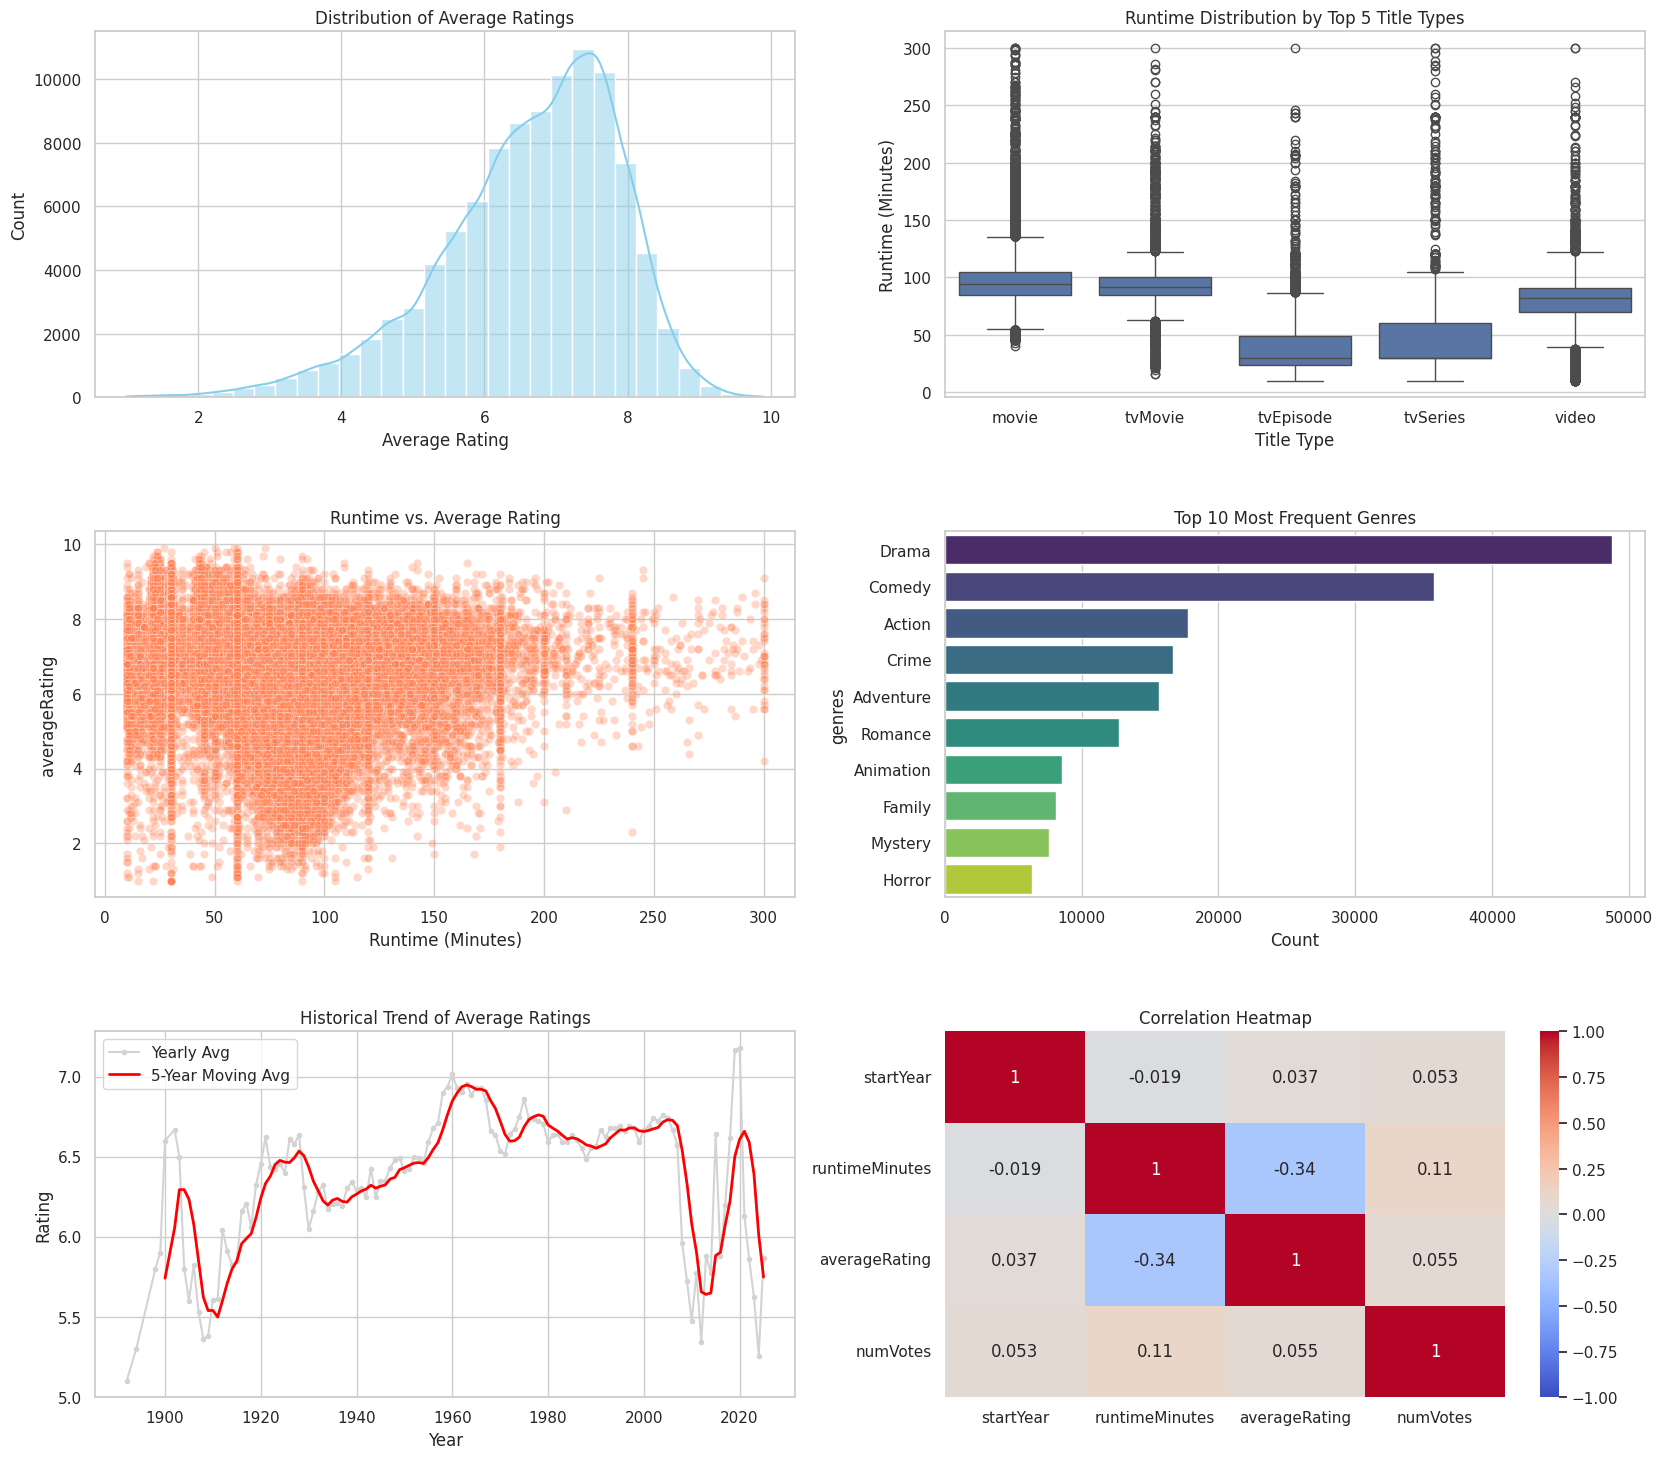

In [5]:
# Create a robust visualization layout
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.tight_layout(pad=6.0)

# 1. Histogram: Average Rating Distribution
sns.histplot(df_clean['averageRating'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Average Ratings')
axes[0, 0].set_xlabel('Average Rating')

# 2. Box Plot: Runtime by Title Type (Top 5 most frequent)
top_types = df_clean['titleType'].value_counts().nlargest(5).index
sns.boxplot(x='titleType', y='runtimeMinutes', data=df_clean[df_clean['titleType'].isin(top_types)], ax=axes[0, 1])
axes[0, 1].set_title('Runtime Distribution by Top 5 Title Types')
axes[0, 1].set_xlabel('Title Type')
axes[0, 1].set_ylabel('Runtime (Minutes)')

# 3. Scatter Plot: Runtime vs. Rating
sns.scatterplot(x='runtimeMinutes', y='averageRating', data=df_clean, alpha=0.3, ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Runtime vs. Average Rating')
axes[1, 0].set_xlabel('Runtime (Minutes)')

# 4. Bar Chart: Top 10 Genres
# Splitting genres and counting
all_genres = df_clean['genres'].str.split(',').explode()
top_genres = all_genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Top 10 Most Frequent Genres')
axes[1, 1].set_xlabel('Count')

# 5. Line Chart: Yearly Average Ratings (with Moving Average)
axes[2, 0].plot(yearly_stats.index, yearly_stats.values, label='Yearly Avg', color='lightgrey', marker='.')
axes[2, 0].plot(rolling_avg.index, rolling_avg.values, label='5-Year Moving Avg', color='red', linewidth=2)
axes[2, 0].set_title('Historical Trend of Average Ratings')
axes[2, 0].set_xlabel('Year')
axes[2, 0].set_ylabel('Rating')
axes[2, 0].legend()

# 6. Heatmap: Numeric Correlations
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[2, 1])
axes[2, 1].set_title('Correlation Heatmap')

# Save figures
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Feature Engineering and Encoding
Before modeling, we must process our categorical variables.
- **Genres:** IMDb formats genres as "Action,Comedy". We will identify the top 10 most common genres across the dataset and create binary flag columns for them (multi-label binarization).
- **Title Type:** We will use `OneHotEncoder` within our `scikit-learn` Pipeline.

In [7]:
# Extract top 10 genres to use as features
top_10_genres_list = top_genres.index.tolist()

# Create binary columns for the top 10 genres
for genre in top_10_genres_list:
    df_clean[f'genre_{genre}'] = df_clean['genres'].str.contains(genre, na=False).astype(int)

# Define our feature matrix (X) and Base Target (y)
feature_cols = ['startYear', 'runtimeMinutes', 'numVotes', 'titleType'] + [f'genre_{g}' for g in top_10_genres_list]
X = df_clean[feature_cols]
y_reg = df_clean['averageRating']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Define ColumnTransformer for preprocessing
numeric_features = ['startYear', 'runtimeMinutes', 'numVotes']
categorical_features = ['titleType']
passthrough_features = [f'genre_{g}' for g in top_10_genres_list] # Already binary

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('pass', 'passthrough', passthrough_features)
    ]
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 80000
Testing set size: 20000


## 7. Regression Task (Predicting Ratings)
**Goal:** Predict the continuous `averageRating` of a title based on its features using Linear Regression.
**Benchmark:** We use `DummyRegressor` (predicts the mean of the training set) to prove our model learns actual patterns.

In [8]:
# 1. Build and train baseline model
baseline_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DummyRegressor(strategy='mean'))
])
baseline_reg.fit(X_train, y_train_reg)
y_pred_base_reg = baseline_reg.predict(X_test)

# 2. Build and train Linear Regression model
model_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
model_reg.fit(X_train, y_train_reg)
y_pred_reg = model_reg.predict(X_test)

# 3. Evaluate both models
def evaluate_regression(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"MSE:  {mean_squared_error(y_true, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"R²:   {r2_score(y_true, y_pred):.4f}\n")

evaluate_regression(y_test_reg, y_pred_base_reg, "Baseline (Dummy Regressor)")
evaluate_regression(y_test_reg, y_pred_reg, "Linear Regression Model")

--- Baseline (Dummy Regressor) ---
MAE:  0.9885
MSE:  1.5677
RMSE: 1.2521
R²:   -0.0001

--- Linear Regression Model ---
MAE:  0.7155
MSE:  0.9172
RMSE: 0.9577
R²:   0.4149



## 8. Classification Task (Predicting Hit vs. Flop)
**Goal:** Predict if a title is a "Hit" (`averageRating` >= 7.0).
**Benchmark:** We use `DummyClassifier` (predicts the most frequent class) to benchmark our Logistic Regression.

In [9]:
# Create binary target variable
y_class = (df_clean['averageRating'] >= 7.0).astype(int)

# Split for classification
X_train_c, X_test_c, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42)

# 1. Build and train baseline model
baseline_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])
baseline_clf.fit(X_train_c, y_train_class)
y_pred_base_class = baseline_clf.predict(X_test_c)

# 2. Build and train Logistic Regression model
model_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
model_clf.fit(X_train_c, y_train_class)
y_pred_class = model_clf.predict(X_test_c)

# 3. Evaluate Classification models
def evaluate_classification(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")

    # Confusion matrix extraction
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"True Positives (TP): {tp}")
    print(f"False Positives (FP): {fp}")
    print(f"True Negatives (TN): {tn}")
    print(f"False Negatives (FN): {fn}\n")

evaluate_classification(y_test_class, y_pred_base_class, "Baseline (Dummy Classifier)")
evaluate_classification(y_test_class, y_pred_class, "Logistic Regression Model")

--- Baseline (Dummy Classifier) ---
Accuracy:  0.5298
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
True Positives (TP): 0
False Positives (FP): 0
True Negatives (TN): 10595
False Negatives (FN): 9405

--- Logistic Regression Model ---
Accuracy:  0.7990
Precision: 0.8252
Recall:    0.7263
F1-Score:  0.7726
True Positives (TP): 6831
False Positives (FP): 1447
True Negatives (TN): 9148
False Negatives (FN): 2574



## 9. Saving Outputs
We will export our cleaned dataset, the list of top genres, and the trained classification pipeline so it can be utilized in an external application.

In [10]:
# Save clean data
csv_filename = "IMDb_Cleaned_Data.csv"
df_clean.to_csv(csv_filename, index=False)

# Save the trained Logistic Regression model
model_filename = "imdb_classification_pipeline.pkl"
joblib.dump(model_clf, model_filename)

# Save the list of top genres for our UI
genres_filename = "top_genres.pkl"
joblib.dump(top_10_genres_list, genres_filename)

print("Project outputs successfully saved to Colab environment:")
print(f"- {csv_filename}")
print(f"- {model_filename}")
print(f"- {genres_filename}")
print("- eda_visualizations.png")

Project outputs successfully saved to Colab environment:
- IMDb_Cleaned_Data.csv
- imdb_classification_pipeline.pkl
- top_genres.pkl
- eda_visualizations.png


## 10. Streamlit Frontend App
Below is the code for a simple Streamlit application. This cell uses magic commands (`%%writefile`) to write the Python code to an `app.py` script.

*To test this locally or on a server, run `streamlit run app.py`.*

In [12]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load resources
@st.cache_resource
def load_assets():
    model = joblib.load("imdb_classification_pipeline.pkl")
    genres = joblib.load("top_genres.pkl")
    return model, genres

model, top_genres = load_assets()

st.title("🎬 IMDb Hit Predictor App")
st.write("Enter the details of a movie/title to predict if it will be a Hit (Rating ≥ 7.0).")

# Layout
col1, col2 = st.columns(2)

with col1:
    start_year = st.number_input("Release Year", min_value=1900, max_value=2030, value=2023)
    runtime = st.number_input("Runtime (Minutes)", min_value=10, max_value=300, value=120)
    title_type = st.selectbox("Title Type", ["movie", "tvSeries", "short", "documentary", "tvEpisode"])

with col2:
    votes = st.number_input("Number of Votes", min_value=100, value=5000)
    selected_genres = st.multiselect("Select Genres", top_genres)

if st.button("Predict Outcome"):
    # Build a dictionary matching the pipeline expectations
    input_data = {
        'startYear': [start_year],
        'runtimeMinutes': [runtime],
        'numVotes': [votes],
        'titleType': [title_type]
    }

    # Set binary flags for all top genres
    for g in top_genres:
        input_data[f'genre_{g}'] = [1 if g in selected_genres else 0]

    # Create DataFrame
    input_df = pd.DataFrame(input_data)

    # Predict
    prediction = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0][1] # Probability of being class 1 (Hit)

    st.divider()
    if prediction == 1:
        st.success(f"🌟 **Prediction: HIT** (Probability: {prob:.2%})")
    else:
        st.error(f"📉 **Prediction: FLOP** (Probability: {prob:.2%})")

Overwriting app.py


In [ ]:
# 1. Install localtunnel
!npm install -g localtunnel

# 2. Get your Endpoint IP (Copy the IP address that prints out here, you will need it as a password!)
print("Copy this IP address to use as your password:")
!wget -q -O - ipv4.icanhazip.com

# 3. Run the Streamlit app in the background
!streamlit run app.py &>/content/logs.txt &

# 4. Start the tunnel to expose port 8501
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 5s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇Copy this IP address to use as your password:
35.243.40.199
⠙⠹⠸⠼⠴⠦⠧your url is: https://cute-mangos-float.loca.lt
